## 📌 **미션 1: 데이터 전처리 및 결측치 처리하기**

**🔥 미션 내용**

- 자동차 연비 데이터(`auto-mpg.csv`)를 로드한 후, 다음 사항을 수행하세요.
1. `horsepower` 열의 결측치가 있는지 확인하고, 결측치를 `horsepower`의 중앙값(median)으로 대체하세요.
2. `car_name` 열을 제거하고 새로운 DataFrame을 만드세요.

In [30]:
import pandas as pd
import numpy as np

df = pd.read_csv('auto-mpg.csv')

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None


In [5]:
# 1
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

df.isnull()

df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

display(df)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [6]:
print(df['horsepower'].isnull().any())

False


In [45]:
# 2.
new_df = df.drop('car name', axis=1)

new_df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1
394,44.0,4,97.0,52,2130,24.6,82,2
395,32.0,4,135.0,84,2295,11.6,82,1
396,28.0,4,120.0,79,2625,18.6,82,1


- df.isnull() 후에 'horsepower'열 결측치를 중앙값 처리 -> TypeError 발생. 결측치 부분에 숫자가 아닌 문자가 들어있었기 때문. (※ df.info()에서 object로 나온 'horsepower'와 'car name'은 숫자가 아닌 문자 포함)
- pd.to_numeric() : 숫자로 바꿀 수 없는게 나오면 결측치(NaN)으로 만듦
- drop() : 특정 열이나 행을 삭제. dropna는 결측치 기준 삭제

## 📌 **미션 2: 조건부 데이터 필터링 및 새로운 열 생성**

**🔥 미션 내용**

- 연비(mpg)가 30 이상인 차량만 필터링하여 `high_mpg`라는 새로운 DataFrame을 생성하세요.
- `high_mpg` 데이터에 무게(weight) 대비 마력(horsepower)의 비율을 나타내는 `hp_weight_ratio`라는 새로운 열을 추가하세요.

In [8]:
# 1.
high_mpg = df[df['mpg'] >= 30]

display(high_mpg.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
51,30.0,4,79.0,70.0,2074,19.5,71,2,peugeot 304
52,30.0,4,88.0,76.0,2065,14.5,71,2,fiat 124b
53,31.0,4,71.0,65.0,1773,19.0,71,3,toyota corolla 1200
54,35.0,4,72.0,69.0,1613,18.0,71,3,datsun 1200
129,31.0,4,79.0,67.0,1950,19.0,74,3,datsun b210


In [9]:
# 2.
high_mpg['hp_weight_ratio'] = high_mpg['horsepower'] / high_mpg['weight']

display(high_mpg['hp_weight_ratio'])

C:\Users\User\AppData\Local\Temp\ipykernel_29136\901218560.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_mpg['hp_weight_ratio'] = high_mpg['horsepower'] / high_mpg['weight']


51     0.033751
52     0.036804
53     0.036661
54     0.042777
129    0.034359
         ...   
390    0.036023
391    0.035443
394    0.024413
395    0.036601
397    0.030147
Name: hp_weight_ratio, Length: 92, dtype: float64

## 📌 **미션 3: 그룹화 및 통계 분석 심화**

**🔥 미션 내용**

- `cylinders`와 `origin`을 기준으로 그룹화하여, 그룹별로 다음을 계산하세요.
1. 연비(mpg)의 평균값과 표준편차
2. 마력(horsepower)의 최대값과 최소값

In [10]:
group_df = df.groupby(['cylinders', 'origin']).agg({
    'mpg' : ['mean', 'std'],    # 1. 연비의 평균값과 표준편차
    'horsepower' : ['max', 'min']   # 2. 마력의 최대값과 최소값
})

display(group_df)

mpg           horsepower      
                       mean       std        max   min
cylinders origin                                      
3         3       20.550000  2.564501      110.0  90.0
4         1       27.840278  4.549560      105.0  52.0
          2       28.411111  6.442503      115.0  46.0
          3       31.595652  5.435787      100.0  52.0
5         2       27.366667  8.228204      103.0  67.0
6         1       19.663514  3.374992      165.0  72.0
          2       20.100000  7.074367      133.0  76.0
          3       23.883333  4.951936      132.0  97.0
8         1       14.963107  2.836284      230.0  90.0

- .agg() : 여러 가지 계산을 한 번에 적용할 때 사용하는 함수
- 평균 mean / 표준편차 std / 분산 var / 최대 max / 최소 min

## 📌 **미션 4: 데이터 시각화 심화 실습**

**🔥 미션 내용**

- 판다스를 이용하여 다음 두 가지 시각화를 수행하세요.
1. `mpg`(연비)와 `weight`(무게)의 관계를 실린더(`cylinders`) 수에 따라 다른 색상으로 나타내는 산점도를 그리세요.
2. `model_year`에 따른 연비(`mpg`)의 변화를 박스플롯으로 시각화하세요.

<Axes: title={'center': 'Weight vs MPG Scatter'}, xlabel='weight', ylabel='mpg'>

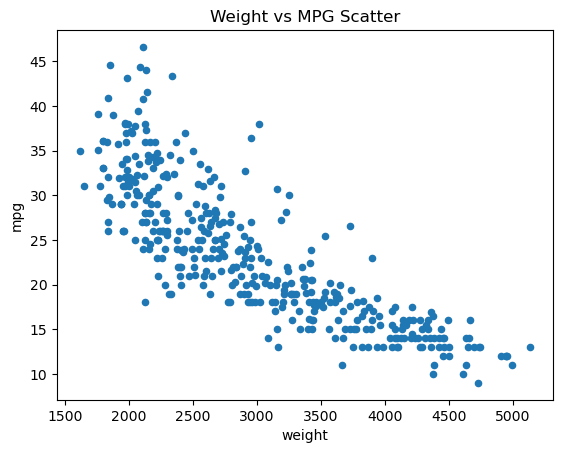

In [34]:
# 1.
df.plot.scatter(x='weight', y='mpg', title='Weight vs MPG Scatter')

<Axes: title={'center': 'mpg'}, xlabel='model year'>

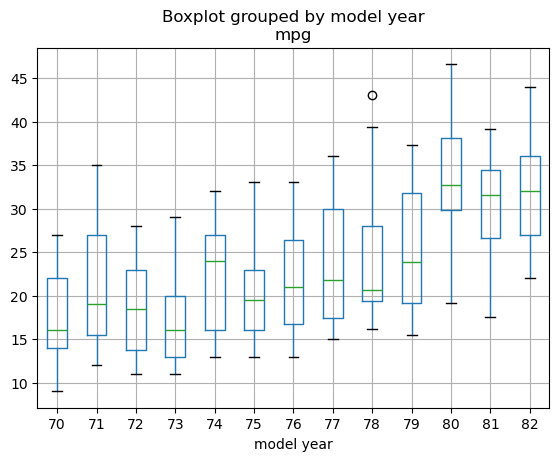

In [35]:
# 2.
df.boxplot(column='mpg', by='model year', grid=True)

-  grid가 True면 격자선 포함. False면 격자선 불포함

## 📌 **미션 5: 상관 분석 및 히트맵 시각화**

**🔥 미션 내용**

- 다음 사항을 수행하여 데이터의 상관관계를 분석하세요.
1. 데이터의 모든 수치형 열 간 상관계수 매트릭스를 구하세요.
2. Seaborn을 활용하여 상관계수 히트맵(heatmap)을 시각화하고, 가장 강한 상관관계(절댓값 기준)를 갖는 두 변수의 이름을 적으세요.

In [ ]:
pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [44]:
# 1.
corr_df= df.select_dtypes(include=['number']).corr()

print(corr_df)

                   mpg  cylinders  displacement    weight  acceleration  \
mpg           1.000000  -0.775396     -0.804203 -0.831741      0.420289   
cylinders    -0.775396   1.000000      0.950721  0.896017     -0.505419   
displacement -0.804203   0.950721      1.000000  0.932824     -0.543684   
weight       -0.831741   0.896017      0.932824  1.000000     -0.417457   
acceleration  0.420289  -0.505419     -0.543684 -0.417457      1.000000   
model year    0.579267  -0.348746     -0.370164 -0.306564      0.288137   
origin        0.563450  -0.562543     -0.609409 -0.581024      0.205873   

              model year    origin  
mpg             0.579267  0.563450  
cylinders      -0.348746 -0.562543  
displacement   -0.370164 -0.609409  
weight         -0.306564 -0.581024  
acceleration    0.288137  0.205873  
model year      1.000000  0.180662  
origin          0.180662  1.000000  


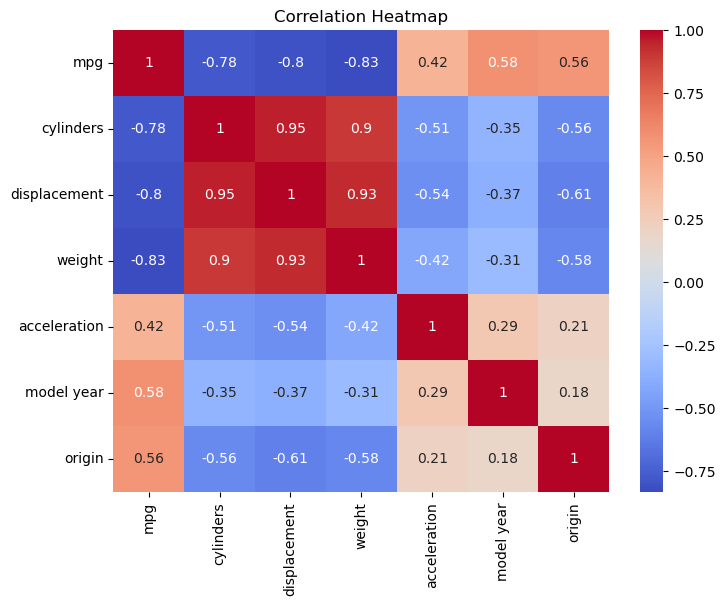

In [41]:
# 2.
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.show()

📝 2번에서 가장 강한 상관관계를 갖는 두 변수
-> 'cylinders'와 'displacement' (상관계수 0.95)


- '수치형 열 간 상관계수' -> 컬럼 숫자값 끼리의 상관계수를 구하겠다는 의미
-  select_dtypes() : 데이터 프레임 내에서 특정 열만 골라낼 때 쓰는 함수. 
    - include=[ ] : [ ]타입만 포함 / exclude=[ ] : [ ]타입만 제외 
- sns.heatmap() : 히트맵 표현
    - df.corr(numeric_only=True) : 숫자 데이터만 가지고 상관계수 계산
    - annot=True : Annotation의 약자로, 상관계수 숫자를 직접 써주는 옵션

## 🎯 학습 후 체크리스트

- [x]  결측치 처리와 데이터 전처리를 수행했다.
- [x]  조건부 필터링과 새로운 열 추가를 할 수 있다.
- [x]  그룹별 심화 통계 분석을 수행했다.
- [x]  다양한 조건과 그룹을 활용한 시각화를 할 수 있다.
- [x]  상관계수를 이해하고 히트맵을 이용해 명확히 표현했다.

## ✏️ 오늘의 학습 회고

- **가장 유용했던 개념은 무엇인가요?** : 특정 열을 삭제하거나 추가하는 연습이 도움이 되었다.
  
- **어려웠던 부분과 해결 방법은?** : 데이터 시각화하는 부분의 코드를 작성하는 것이 헷갈렸다. 박스플롯도 산점도처럼 x와 y로 입력했다가 오류나서 노션을 다시 읽어보니 by로 작성해야함을 알게 되었다. 그리고 산점도의 변수가 두 개인데, 새로운 변수 'cylinders'를 추가하고 'wegiht' <-> 'cylinders'와 'mpg' <-> 'cylinders'간의 관계에 따라 색을 다르게 칠해야 하는걸까? 어떻게 구현해야하는지 잘 모르겠다.
  
- **다음 번 학습에서 더 깊게 다뤄보고 싶은 주제는?** 차트 시각화 연습을 더 해야할 것 같다.